# Object Detection Techniques

We look at simple techniques like morphological operations and intensity thresholding techniques to detect objects in images.

In [32]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [11]:
# Load images to illustrate methods
img = cv2.imread('../images/tissue_img.png')

# Thresholding techiques

Thresholding techniques works by automatically finding optimal thresholds for pixel intensity cutoffs, producing binary masks of object of interests located in the foreground.

## Otsu's Thresholding

Selects intensity cutoffs by minimizing intra-class variances (e.g. within foreground/background classes).

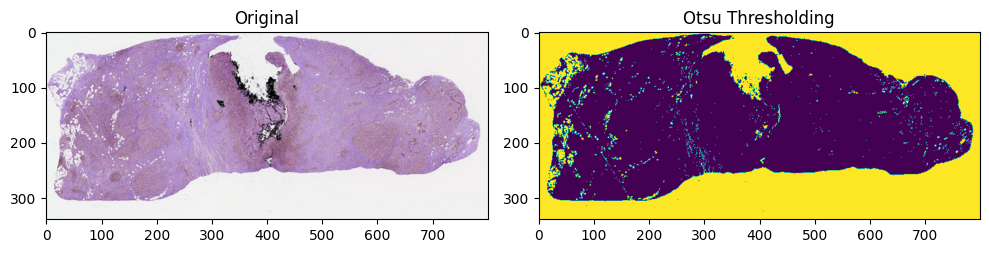

In [ ]:
# Convert to greyscale for binary thresholding
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply otsu thresholding to get binary mask
_, otsu_mask = cv2.threshold(
    gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Visualize original vs binary mask
fig, axes = plt.subplots(1, 2, figsize=(10, 15))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[1].imshow(otsu_mask)
axes[1].set_title("Otsu Thresholding")

plt.tight_layout()
plt.show()

## Adaptive Mean Thresholding
Selects local thresholding for each neighborhood to do adaptive thresholding, uses multiple instead of one global pixel intensity cutoff.

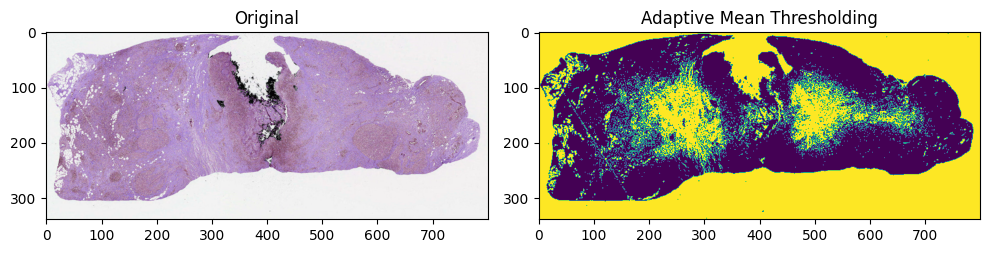

In [25]:
# Convert to greyscale for binary thresholding
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply adaptive mean thresholding to get binary mask
adaptive_mean_mask = cv2.adaptiveThreshold(
    gray_image, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    blockSize = 199, # Controls the size of local neighborhood
    C = 5 # Constant subtracted from mean for thresholding
)

# Visualize original vs binary mask
fig, axes = plt.subplots(1, 2, figsize=(10, 15))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[1].imshow(adaptive_mean_mask)
axes[1].set_title("Adaptive Mean Thresholding")

plt.tight_layout()
plt.show()

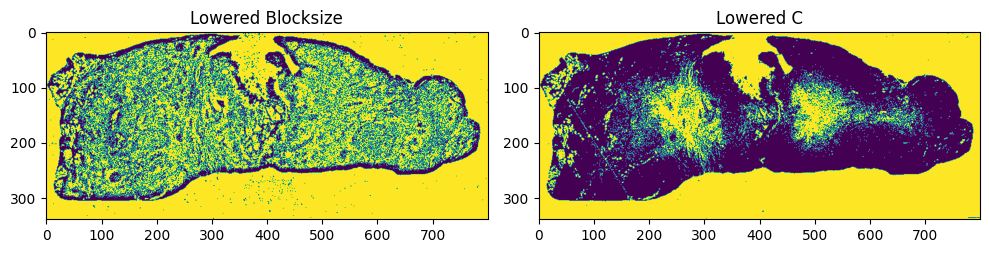

In [31]:
# Effects of blocksize and constant parameters #
# Decreasing blocksize means smaller local neighborhood > more local features preserved
lowered_blocksize = cv2.adaptiveThreshold(
    gray_image, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    blockSize = 21,
    C = 5
)

# Decreasing C increases threshold > more foreground pixels included
lowered_C = cv2.adaptiveThreshold(
    gray_image, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    blockSize = 199,
    C = 1
)


# Visualize original vs binary mask
fig, axes = plt.subplots(1, 2, figsize=(10, 15))

axes[0].imshow(lowered_blocksize)
axes[0].set_title("Lowered Blocksize")
axes[1].imshow(lowered_C)
axes[1].set_title("Lowered C")

plt.tight_layout()
plt.show()

# Morphological operations
Finetuning operations used to refine binary masks e.g. plug small holes, smoothen out mask edges

## Erosion
Shrinks foreground pixels, useful for disconnecting masks that are merged together.

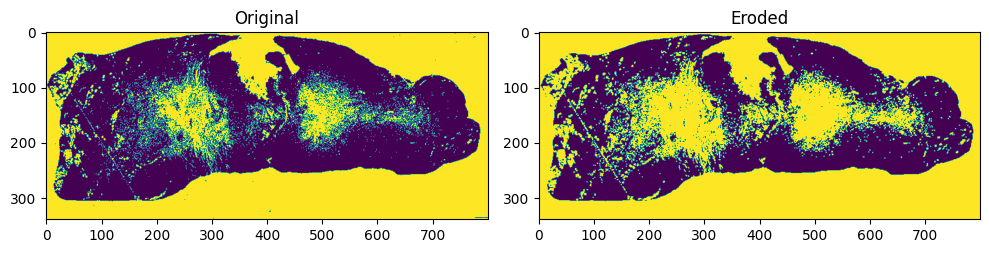

In [40]:
# Use binary mask from earlier
binary_mask = adaptive_mean_mask

# Apply erosion: increase kernel size for more erosion
kernel = np.ones((2, 2), np.uint8)    
inverse_binary_mask = cv2.bitwise_not(binary_mask)                       
inverse_eroded_mask = cv2.erode(inverse_binary_mask, kernel, 1)
eroded_mask = cv2.bitwise_not(inverse_eroded_mask)

# Visualize original vs eroded mask
fig, axes = plt.subplots(1, 2, figsize=(10, 15))

axes[0].imshow(binary_mask)
axes[0].set_title("Original")
axes[1].imshow(eroded_mask)
axes[1].set_title("Eroded")

plt.tight_layout()
plt.show()

## Dilation
Expands foreground pixels, can be used to connect disjointed components of mask and plug small holes.

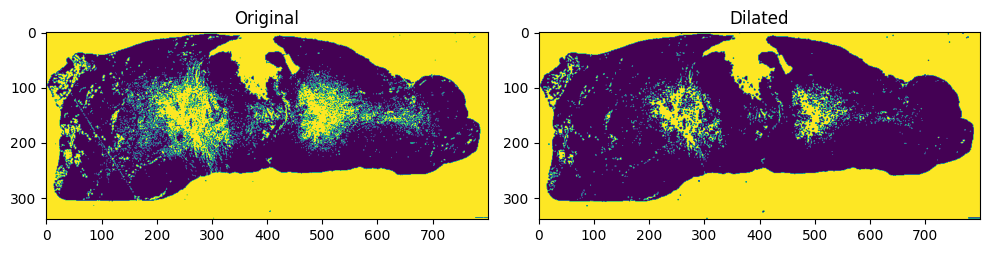

In [41]:
# Use binary mask from earlier
binary_mask = adaptive_mean_mask

# Apply dilation: increase kernel size for more dilation
kernel = np.ones((2, 2), np.uint8)    
inverse_binary_mask = cv2.bitwise_not(binary_mask)                       
inverse_dilated_mask = cv2.dilate(inverse_binary_mask, kernel, 1)
dilated_mask = cv2.bitwise_not(inverse_dilated_mask)

# Visualize original vs dilated mask
fig, axes = plt.subplots(1, 2, figsize=(10, 15))

axes[0].imshow(binary_mask)
axes[0].set_title("Original")
axes[1].imshow(dilated_mask)
axes[1].set_title("Dilated")

plt.tight_layout()
plt.show()

## Closing
Combines dilation followed by erosion, useful for noise removal.

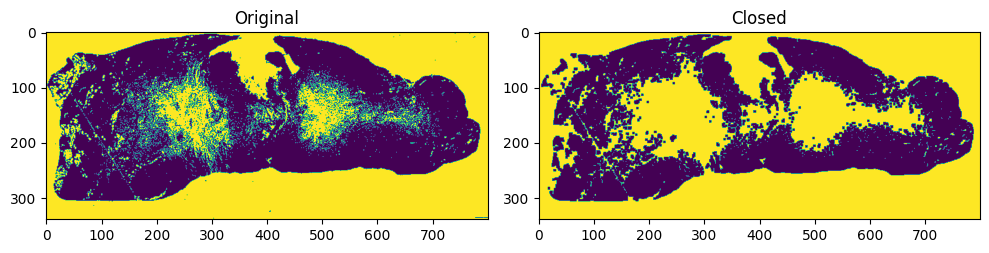

In [ ]:
# Use binary mask from earlier
binary_mask = adaptive_mean_mask

# Apply closing: increase kernel size for more aggressive closing
kernel = np.ones((4, 4), np.uint8)    
closed_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)

# Visualize original vs closed mask
fig, axes = plt.subplots(1, 2, figsize=(10, 15))

axes[0].imshow(binary_mask)
axes[0].set_title("Original")
axes[1].imshow(closed_mask)
axes[1].set_title("Closed")

plt.tight_layout()
plt.show()

## Opening
Combines erosion followed by dilation, useful for noise removal.

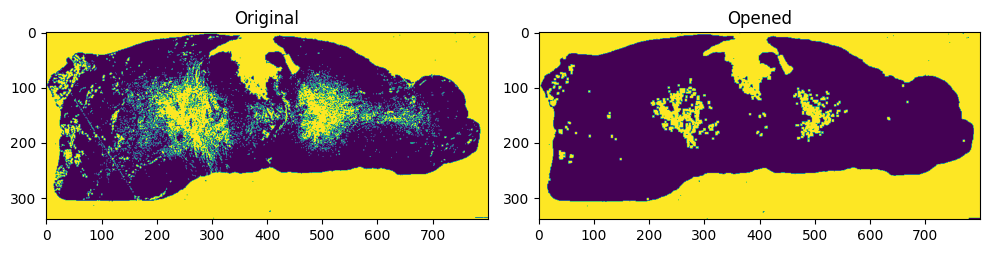

In [ ]:
# Use binary mask from earlier
binary_mask = adaptive_mean_mask

# Apply opening: increase kernel size for more aggresive opening
kernel = np.ones((4, 4), np.uint8)    
opened_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)

# Visualize original vs opened mask
fig, axes = plt.subplots(1, 2, figsize=(10, 15))

axes[0].imshow(binary_mask)
axes[0].set_title("Original")
axes[1].imshow(opened_mask)
axes[1].set_title("Opened")

plt.tight_layout()
plt.show()

# Considerations

1. The simple techniques illustrated here are dependent on good contrast between the object of interest and background to work. A noisy background might result in masks that capture features unrelated to the object you want to segment.

2. Consider other image enhancement effects like gaussian blurring or denoising to increase contrast between the background and your object of interest for better segmentation results.

3. For images with multiple varying objects (e.g. multi-class objects), a more sophisticated image segmentation deep-learning model like SAM or ResNet might work better at object detection.